### Crop Background Pixels from Parkinson's Disease Astrocyte Maps

#### Crop PD Astrocyte Maps Using Healthy Reference Bounds

Match each PD map to its corresponding healthy astrocyte, apply the saved healthy cropping bounds with padding, compare label pixel counts before and after cropping, save the cropped PD segmentation maps, and visualize the cropped outputs.


Processing PD Astrocyte: pd_astro_1_40_55.npy (Using bounds from Healthy_astro_1_stitched.npy)
**Before Cropping:**

 **Pixel Count for Each Label:**
Label 0: 397733 pixels
Label 1: 483037 pixels
Label 2: 877520 pixels
Label 3: 15948974 pixels
**After Cropping:**

 **Pixel Count for Each Label:**
Label 0: 397733 pixels
Label 1: 483037 pixels
Label 2: 877520 pixels
Label 3: 11784110 pixels
Cropped PD Astrocyte saved to: Step_5_Cropped_PD_NPYs/pd_astro_1_40_55.npy


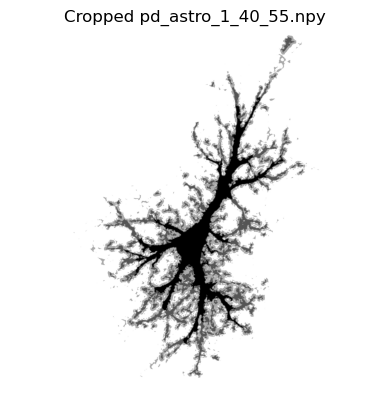


Processing PD Astrocyte: pd_astro_1_60_70.npy (Using bounds from Healthy_astro_1_stitched.npy)
**Before Cropping:**

 **Pixel Count for Each Label:**
Label 0: 397733 pixels
Label 1: 483037 pixels
Label 2: 992232 pixels
Label 3: 15834262 pixels
**After Cropping:**

 **Pixel Count for Each Label:**
Label 0: 397733 pixels
Label 1: 483037 pixels
Label 2: 992232 pixels
Label 3: 11669398 pixels
Cropped PD Astrocyte saved to: Step_5_Cropped_PD_NPYs/pd_astro_1_60_70.npy


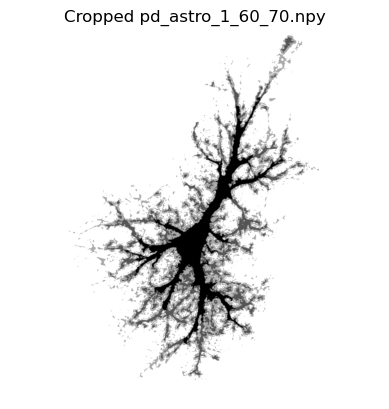


Processing PD Astrocyte: pd_astro_1_80_85.npy (Using bounds from Healthy_astro_1_stitched.npy)
**Before Cropping:**

 **Pixel Count for Each Label:**
Label 0: 397733 pixels
Label 1: 483037 pixels
Label 2: 1284850 pixels
Label 3: 15541644 pixels
**After Cropping:**

 **Pixel Count for Each Label:**
Label 0: 397733 pixels
Label 1: 483037 pixels
Label 2: 1284850 pixels
Label 3: 11376780 pixels
Cropped PD Astrocyte saved to: Step_5_Cropped_PD_NPYs/pd_astro_1_80_85.npy


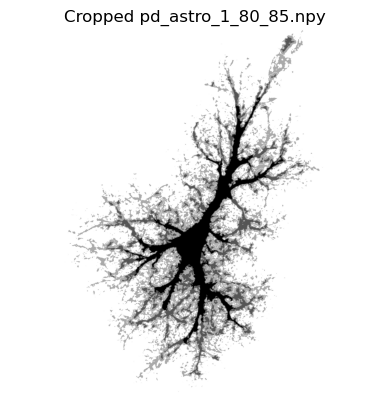

In [1]:
import numpy as np
import os
import json
import re
import matplotlib.pyplot as plt

# Directories
input_dir_pd = "Step_4_Stitched_PD_NPYs"
output_dir_pd = "Step_5_Cropped_PD_NPYs"
bounds_file = "Step_1_Cropping_Bounds/healthy_cropping_bounds.json"
os.makedirs(output_dir_pd, exist_ok=True)

def load_npy(file_path):
    return np.load(file_path)

def crop_using_fixed_bounds(mask, fixed_bounds, padding=5):
    """Crop the image using predefined bounds to ensure alignment."""
    min_y, max_y, min_x, max_x = fixed_bounds
    min_y = max(0, min_y - padding)
    max_y = min(mask.shape[0], max_y + padding)
    min_x = max(0, min_x - padding)
    max_x = min(mask.shape[1], max_x + padding)
    return mask[min_y:max_y, min_x:max_x]

def print_label_pixel_counts(mask):
    """Print the count of each label in the mask."""
    unique_labels, counts = np.unique(mask, return_counts=True)
    label_counts = dict(zip(unique_labels, counts))
    print("\n **Pixel Count for Each Label:**")
    for label, count in label_counts.items():
        print(f"Label {label}: {count} pixels")
    return label_counts

def visualize_mask(mask, title="Cropped Astrocyte"):
    """Display the cropped image."""
    plt.imshow(mask, cmap='gray')
    plt.title(title)
    plt.axis("off")
    plt.show()

# Load saved cropping bounds (computed from healthy astrocytes)
with open(bounds_file, "r") as f:
    bounds_dict = json.load(f)

# Function to extract astrocyte number from PD filename
def extract_astro_id(pd_filename):
    match = re.search(r"pd_astro_(\d+)", pd_filename)  # Extract the numeric ID
    if match:
        return f"Healthy_astro_{match.group(1)}_stitched.npy"  # Convert it to match healthy filename
    return None

# Crop each PD astrocyte using corresponding healthy astrocyte's bounds
for filename in sorted(os.listdir(input_dir_pd)):
    if filename.endswith(".npy"):
        pd_file_path = os.path.join(input_dir_pd, filename)

        # Extract the corresponding healthy astrocyte filename
        healthy_filename = extract_astro_id(filename)

        if not healthy_filename or healthy_filename not in bounds_dict:
            print(f"⚠️ Skipping {filename} (No matching healthy bounds found for {healthy_filename})")
            continue

        print(f"\nProcessing PD Astrocyte: {filename} (Using bounds from {healthy_filename})")

        # Load PD image
        pd_mask = load_npy(pd_file_path)

        # Print pixel counts before cropping
        print("**Before Cropping:**")
        label_counts_before = print_label_pixel_counts(pd_mask)

        # Crop using stored healthy bounds
        bounds = bounds_dict[healthy_filename]  # Use healthy astrocyte's bounds
        cropped_pd = crop_using_fixed_bounds(pd_mask, bounds, padding=5)

        # Print pixel counts after cropping
        print("**After Cropping:**")
        label_counts_after = print_label_pixel_counts(cropped_pd)

        # Save cropped PD astrocyte
        output_path = os.path.join(output_dir_pd, filename)
        np.save(output_path, cropped_pd)
        print(f"Cropped PD Astrocyte saved to: {output_path}")

        # Visualize cropped image
        visualize_mask(cropped_pd, title=f"Cropped {filename}")
